<a href="https://colab.research.google.com/github/FatmaAMR/Spam-detector/blob/main/Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Setup and Data Collection**



*Installation libraries, and reading data*

In [ ]:
!pip install kaggle

!pip install scikit-learn

^C


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [ ]:
!unzip archive\ \(4\).zip

Archive:  archive (4).zip
replace spam_ham_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
data = pd.read_csv('spam_ham_dataset.csv')
data

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


## **Data Cleaning**

### ***missing data check***

Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64


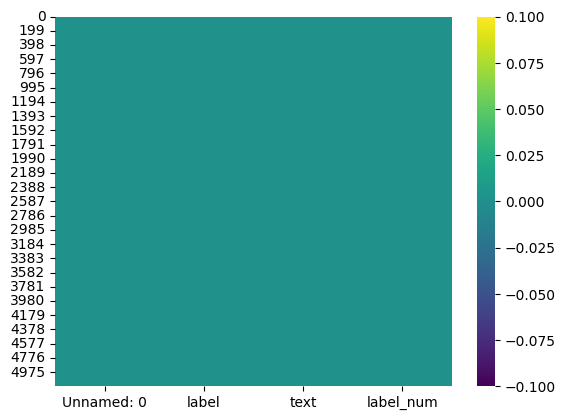

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


In [ ]:
print(data.isnull().sum())
sns.heatmap(data.isnull(), cmap='viridis')
plt.show()
data
#so no missing data

### ***droping uninque-value and repeared coulumns***

In [ ]:
data = data.drop(['label'], axis=1)
data = data.drop(['Unnamed: 0'], axis=1)
data

,text,label_num
0,Subject: enron methanol ; meter # : 988291 thi...,0
1,"Subject: hpl nom for january 9 , 2001 ( see at...",0
2,"Subject: neon retreat ho ho ho , we ' re aroun...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs this deal is to b...,0
...,...,...
5166,Subject: put the 10 on the ft the transport vo...,0
5167,Subject: 3 / 4 / 2000 and following noms hpl c...,0
5168,Subject: calpine daily gas nomination > > juli...,0
5169,Subject: industrial worksheets for august 2000...,0


## ***Text Preprocessing***

In [ ]:
data['text'] = data['text'].apply(lambda x: x.replace('\r\n', ' '))
print('After:\n\n', data['text'].iloc[3])

After:

 Subject: photoshop , windows , office . cheap . main trending abasements darer prudently fortuitous undergone lighthearted charm orinoco taster railroad affluent pornographic cuvier irvin parkhouse blameworthy chlorophyll robed diagrammatic fogarty clears bayda inconveniencing managing represented smartness hashish academies shareholders unload badness danielson pure caffein spaniard chargeable levin 


In [ ]:
#nltk.download('punkt') # Downloading necessary data


stemmer = PorterStemmer() # Creatting a PorterStemmer object

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
cormpus=[]
stopwords_set = set(stopwords.words('english'))
for i in range(len(data)):
  text = data['text'].iloc[i].lower()
  text = text.translate(str.maketrans('', '', string.punctuation)).split()
  text = [stemmer.stem(word) for word in text if word not in stopwords_set]
  text = ' '.join(text)
  cormpus.append(text)

In [ ]:
#for i in range(len(cormpus)):
  #print(cormpus[i])
print(cormpus[6])

subject spring save certif take 30 save 30 use custom appreci spring save certif foot locker ladi foot locker kid foot locker onlin store welcom custom appreci spring save certif use special certif receiv 30 purchas either store onlin hurri 4 day sale begin thursday march 22 end sunday march 25 share save today e mail offer friend mani item alreadi reduc 30 discount taken lowest sale price click print custom appreci spring save certif must present coupon foot locker ladi foot locker kid foot locker store u foot locker canada particip program readi set save spring save discount automat appear use link type camlem 21 promot code box checkout footlock com certif code camlem 21 ladyfootlock com certif code camlem 21 kidsfootlock com certif code camlem 21 rememb return hassl free simpli bring item store nationwid mail left regist today learn new product promot event special simpli click term condit exclus appli pleas see manag complet detail certif must present time purchas cannot use conju

In [ ]:
vercorizer = CountVectorizer()
X = vercorizer.fit_transform(cormpus).toarray()
y = data['label_num'] #convert text data into a numerical representation
"""

It does this by counting the frequency of each unique word in the text data and creating a sparse matrix where each row represents a document and each column represents a unique word.

"""

## ***Model Building***

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
R = RandomForestClassifier(n_jobs=-1)
R.fit(x_train, y_train)

RandomForestClassifier(n_jobs=-1)

## **Model Evaluation**

In [ ]:
y_pred = R.predict(x_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.9748792270531401
Precision: 0.9525423728813559
Recall: 0.9590443686006825
F1-score: 0.95578231292517
Confusion Matrix:
 [[728  14]
 [ 12 281]]


## **Deployment**

In [ ]:
def is_spam(email):
  email_text = email.lower().translate(str.maketrans('', '', string.punctuation)).split()
  email_text = [stemmer.stem(word) for word in email_text if word not in stopwords_set]
  email_text = ' '.join(email_text)
  email_corpus = [email_text]
  converted_email = vercorizer.transform(email_corpus)
  R.predict(converted_email)
  print(x[0])
  if x[0] == 1:
    return 'ham'
  else:
    return 'spam'

print(is_spam(data.text[3]))
print(is_spam(data.text[2]))

0
spam
0
spam
